In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from sklearn.metrics import classification_report

In [ ]:
train_dir = "/content/drive/MyDrive/AI_ML/workshop5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI_ML/workshop5/FruitinAmazon/test"

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


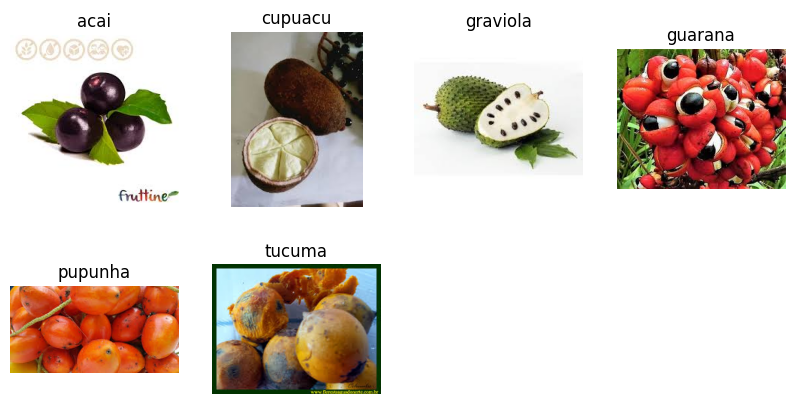

In [ ]:
class_names = os.listdir(train_dir)
print("Classes:", class_names)

plt.figure(figsize=(10, 5))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    img_name = np.random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, len(class_names)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
corrupted = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [ ]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

rescale = layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalize
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
num_classes = len(class_names)

model = keras.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2), strides=2),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.0920 - loss: 2.7052
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step - accuracy: 0.1111 - loss: 2.7137 - val_accuracy: 0.0000e+00 - val_loss: 1.9495
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.1743 - loss: 2.0286
Epoch 2: val_accuracy improved from 0.00000 to 0.05556, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.1944 - loss: 1.8786 - val_accuracy: 0.0556 - val_loss: 1.7499
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.2896 - loss: 1.6880
Epoch 3: val_accuracy improved from 0.05556 to 0.16667, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.3750 - loss: 1.6665 - val_accuracy: 0.1667 - val_loss: 1.6969
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.3708 - loss: 1.5295
Epoch 4: val_accuracy improved from 0.16667 to 0.61111, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.3750 - loss: 1.5021 - val_accuracy: 0.6111 - val_loss: 1.3658
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5090 - loss: 1.2352
Epoch 5: val_accuracy did not improve from 0.61111
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.5556 - loss: 1.2016 - val_accuracy: 0.6111 - val_loss: 1.2382
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.6830 - loss: 0.9360
Epoch 6: val_accuracy improved from 0.61111 to 0.83333, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.6806 - loss: 0.9120 - val_accuracy: 0.8333 - val_loss: 1.0454
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9333 - loss: 0.5695
Epoch 7: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.9167 - loss: 0.5927 - val_accuracy: 0.8889 - val_loss: 0.5831
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9653 - loss: 0.3010
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.9722 - loss: 0.3015 - val_accuracy: 0.7778 - val_loss: 0.8808
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9260 - loss: 0.2690
Epoch 9: val_accuracy improved from 0.88889 to 1.00000, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.9583 - loss: 0.2213 - val_accuracy: 1.0000 - val_loss: 0.2646
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9837 - loss: 0.1535
Epoch 10: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.9861 - loss: 0.1343 - val_accuracy: 0.8333 - val_loss: 0.4546
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 1.0000 - loss: 0.0738
Epoch 11: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step - accuracy: 1.0000 - loss: 0.0638 - val_accuracy: 0.8889 - val_loss: 0.2726
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 0.0232
Epoch 12: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 1.0000 - loss: 0.0218 - val_accuracy: 0.9444 - val_loss: 0.2002
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 1.0000 - loss

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,639,668 (48.22 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,426,446 (32.14 MB)

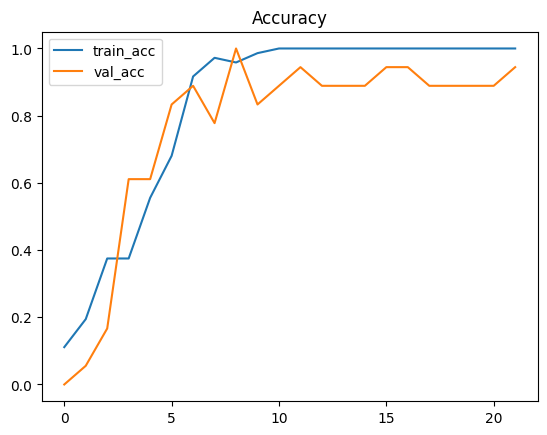

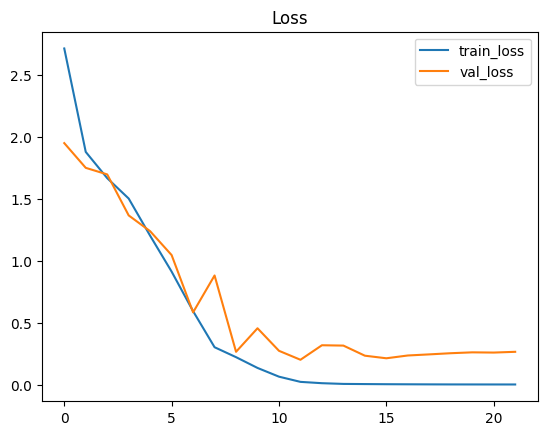

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9444 - loss: 0.2002
Validation Accuracy: 0.9444444179534912


In [ ]:
model.save("cnn_model.h5")

loaded_model = keras.models.load_model("cnn_model.h5")

loaded_model.evaluate(val_ds)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9444 - loss: 0.2002 


[0.2002454400062561, 0.9444444179534912]

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Get unique labels actually present in y_true
labels_present = np.unique(y_true)

# Create target_names for only the labels present
# Ensure class_names is accessible and correctly ordered if using direct indexing
# Assuming class_names is ordered according to the integer labels generated by image_dataset_from_directory
target_names_for_report = [class_names[i] for i in labels_present]

print(classification_report(
    y_true,
    y_pred,
    labels=labels_present,
    target_names=target_names_for_report
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
              precision    recall  f1-score   support

     pupunha       1.00      0.67      0.80         3
      tucuma       0.94      1.00      0.97        15

    accuracy                           0.94        18
   macro avg       0.97      0.83      0.88        18
weighted avg       0.95      0.94      0.94        18

